# Trabajo integrador:
## Análisis de ventas de electrodomésticos

### Caso:
Una empresa dedicada a la venta de electrodomésticos comercializa sus productos a través de distintas sucursales y también mediante su canal online. La empresa cuenta con diferentes vendedores, categorías de productos, medios de pago y tipos de clientes. Además, registra información relacionada con descuentos, costos de envío, estado de las ventas y calificaciones de los clientes.


## 1. Importación y reconocimiento del archivo

Importar la hoja **Ventas** utilizando Pandas.

Realizar una primera exploración utilizando algunas de las herramientas trabajadas:

    df.head()
    df.shape
    df.columns
    df.dtypes
    df.info()
    df.describe() 

A partir de esta exploración, responder:
- ¿Cuántos registros contiene el archivo?
- ¿Cuántas variables posee?
- ¿Qué variables son numéricas?
- ¿Qué variables son categóricas?
- ¿Qué información representa cada fila?

Pueden consultar también la hoja **Diccionario** para conocer el significado de las variables.


In [20]:
import pandas as pd

print("Importación y reconocimiento del archivo")

df = pd.read_excel("ventas_electrodomesticos_integrador.xlsx", sheet_name="Ventas")

print("Exploración inicial del DataFrame")
print(df.head())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())
print(df.describe())


#¿Cuántos registros contiene el archivo?
contar_registros = df.shape[0]
print(f"El archivo contiene {contar_registros} registros.")

#¿Cuántas variables posee?
cantidad_variables = df.shape[1]
print(f"El archivo posee {cantidad_variables} variables.")

#¿Qué variables son numéricas?
variables_numericas = df.select_dtypes(include=['number']).columns.tolist()
print(f"Las variables numéricas son: {variables_numericas}")

#¿Qué variables son categóricas?
variables_categoricas = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Las variables categóricas son: {variables_categoricas}")

#¿Qué información representa cada fila?
print("Cada fila representa un registro de venta de electrodomésticos, incluyendo información sobre el producto, la fecha de venta, " \
"el precio, la cantidad vendida y otros detalles relevantes.")


Importación y reconocimiento del archivo
Exploración inicial del DataFrame
  ID_Venta      Fecha Sucursal      Ciudad       Canal         Vendedor  \
0     V001 2026-08-01   Centro        CABA  Presencial      Lucía Gómez   
1     V002 2026-08-01    Norte  San Isidro      Online     Martín López   
2     V003 2026-08-02    Oeste       Morón  Presencial       Carla Ruiz   
3     V004 2026-08-02   Centro        CABA      Online  Diego Fernández   
4     V005 2026-08-03      Sur     Quilmes  Presencial      Sofía Pérez   

          Categoria                  Producto      Marca  Cantidad  \
0         Heladeras             Heladera 320L    FríoMax         1   
1       Televisores               Smart TV 50     Visión         1   
2  Pequeños electro            Microondas 28L  HogarPlus         2   
3        Lavarropas            Lavarropas 8kg   AquaWash         1   
4     Climatización  Aire acondicionado 3000F    ClimaAR         1   

   Precio_Unitario  Descuento_Porc       Medio_Pago T

## 2. Calidad y preparación de los datos 

Analizar la calidad del conjunto de datos. Deberán identificar, cuando corresponda: 

- valores faltantes 
- registros duplicados 
- posibles inconsistencias 
- tipos de datos que requieran alguna modificación 
- columnas que puedan ser útiles para realizar nuevos cálculos 

No es necesario modificar todos los datos. Deberán decidir qué operaciones son pertinentes y 
justificar brevemente las decisiones tomadas.


In [21]:
# Cantidad valores faltantes
valores_faltantes = df.isnull().sum()
print("\nValores faltantes por columna:")
print(valores_faltantes)

# Cantidad de valores duplicados
valores_duplicados = df.duplicated().sum()
print(f"\nNúmero de registros duplicados: {valores_duplicados}")

# Posibles inconsistencias
print("\nValores únicos de variables categóricas:")

columnas_categoricas = df.select_dtypes(include=["object", "string"]).columns

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(df[columna].value_counts(dropna=False))

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Resumen estadístico para detectar valores sospechosos
print("\nResumen de variables numéricas:")
print(df.describe())

# Reemplazar los descuentos faltantes por 0
df["Descuento_Porc"] = df["Descuento_Porc"].fillna(0)



Valores faltantes por columna:
ID_Venta           0
Fecha              0
Sucursal           0
Ciudad             0
Canal              0
Vendedor           0
Categoria          0
Producto           0
Marca              0
Cantidad           0
Precio_Unitario    0
Descuento_Porc     1
Medio_Pago         1
Tipo_Cliente       0
Costo_Envio        0
Estado_Venta       0
Calificacion       2
dtype: int64

Número de registros duplicados: 0

Valores únicos de variables categóricas:

ID_Venta:
ID_Venta
V001    1
V002    1
V003    1
V004    1
V005    1
V006    1
V007    1
V008    1
V009    1
V010    1
V011    1
V012    1
V013    1
V014    1
V015    1
V016    1
V017    1
V018    1
V019    1
V020    1
V021    1
V022    1
V023    1
V024    1
V025    1
V026    1
V027    1
V028    1
V029    1
V030    1
V031    1
V032    1
V033    1
V034    1
V035    1
V036    1
Name: count, dtype: int64

Sucursal:
Sucursal
Centro    10
Norte      9
Sur        9
Oeste      8
Name: count, dtype: int64

Ciudad:
Ciudad
C

## Interpretación

- No se eliminaron registros, ya que no se encontraron filas duplicadas.

- Se mantuvieron los valores faltantes de Medio_Pago y Calificacion, ya que no contamos con información suficiente para determinar sus valores reales.

- Los valores faltantes de Descuento_Porc se reemplazaron por 0, considerando que representan operaciones en las que no se registró un descuento.

- No se modificaron las variables de categoría, ya que no se encontraron inconsistencias evidentes en sus valores.

- Los tipos de datos se consideraron adecuados para los análisis posteriores.


## 3. Crear nuevas variables 
A partir de las columnas existentes, crear al menos dos nuevas variables que resulten útiles para el análisis.  También podrían calcular el importe luego del descuento. A partir de estas variables pueden surgir otros cálculos o clasificaciones. Deberán explicar qué 
variables crearon y para qué pueden resultar útiles.

In [22]:
# Importe original de la venta antes de aplicar descuentos.
df["Importe_Bruto"] = df["Cantidad"] * df["Precio_Unitario"]

# Importe descontado sobre el valor bruto de la venta.
df["Importe_Descuento"] = (
    df["Importe_Bruto"] * df["Descuento_Porc"]
)

# Importe final luego de aplicar el descuento y sumar el costo de envío.
df["Importe_Final"] = (
    df["Importe_Bruto"]
    - df["Importe_Descuento"]
    + df["Costo_Envio"]
)

print(
    df[
        [
            "ID_Venta",
            "Cantidad",
            "Precio_Unitario",
            "Descuento_Porc",
            "Costo_Envio",
            "Importe_Bruto",
            "Importe_Descuento",
            "Importe_Final"
        ]
    ].head()
)

  ID_Venta  Cantidad  Precio_Unitario  Descuento_Porc  Costo_Envio  \
0     V001         1           780000            0.10            0   
1     V002         1           620000            0.05        18000   
2     V003         2           185000            0.00            0   
3     V004         1           690000            0.12        22000   
4     V005         1           540000            0.08            0   

   Importe_Bruto  Importe_Descuento  Importe_Final  
0         780000            78000.0       702000.0  
1         620000            31000.0       607000.0  
2         370000                0.0       370000.0  
3         690000            82800.0       629200.0  
4         540000            43200.0       496800.0  


## Interpretación

- Importe_Bruto: Representa el valor total de la venta antes de aplicar cualquier descuento.
- Importe_Descuento: Representa el monto del descuento aplicado a la venta.
- Importe_Final: Representa el valor final de la venta después de aplicar el descuento y sumar el costo de envío.

## 4. Análisis exploratorio 

Realizar un análisis general de las ventas utilizando las herramientas estadísticas trabajadas durante el curso.

Pueden analizar variables como: 
- cantidad de productos vendidos 
- precio unitario 
- descuentos 
- costos de envío 
- calificaciones 
- importes de venta


In [23]:
#cantidad de productos vendidos 
cantidad_productos_vendidos = df["Cantidad"].sum()
print(f"\nCantidad total de productos vendidos: {cantidad_productos_vendidos}")

#facturacion total
facturacion_total = df["Importe_Final"].sum()
print(f"Facturación total: {facturacion_total:.2f}")

#precio unitario 
precio_unitario_promedio = df["Precio_Unitario"].mean()
print(f"Precio unitario promedio: {precio_unitario_promedio:.2f}")

#descuentos 
descuentos_promedio = df["Descuento_Porc"].mean()
print(f"Descuento promedio: {descuentos_promedio:.2%}")

#costos de envío 
costos_envio_promedio = df["Costo_Envio"].mean()
print(f"Costo de envío promedio: {costos_envio_promedio:.2f}")

#calificaciones 
calificaciones_promedio = df["Calificacion"].mean()
print(f"Calificación promedio: {calificaciones_promedio:.2f}")

#importes de venta
importes_venta_promedio = df["Importe_Final"].mean()
print(f"Importe de venta promedio: {importes_venta_promedio:.2f}")

#venta maxima y minima
venta_maxima = df["Importe_Final"].max()
venta_minima = df["Importe_Final"].min()
print(f"Venta máxima: {venta_maxima:.2f}")
print(f"Venta mínima: {venta_minima:.2f}")

#rangos cuartiles de las ventas
cuartiles = df["Importe_Final"].quantile([0.25, 0.5, 0.75])
print(f"cuartiles de las ventas: \n{cuartiles}")

#desviación estándar de las ventas
desviacion_estandar = df["Importe_Final"].std()
print(f"Desviación estándar de las ventas: {desviacion_estandar:.2f}")

#obtener limites superior e inferior de las ventas
q1 = df["Importe_Final"].quantile(0.25)
q3 = df["Importe_Final"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(f"Límite inferior de las ventas: {limite_inferior:.2f}")
print(f"Límite superior de las ventas: {limite_superior:.2f}")

ventas_atipicas = df[
    (df["Importe_Final"] < limite_inferior) |
    (df["Importe_Final"] > limite_superior)
]

print("\nPosibles ventas atípicas:")
print(ventas_atipicas[["ID_Venta", "Importe_Final"]])



Cantidad total de productos vendidos: 47
Facturación total: 17359250.00
Precio unitario promedio: 478138.89
Descuento promedio: 7.42%
Costo de envío promedio: 10833.33
Calificación promedio: 4.29
Importe de venta promedio: 482201.39
Venta máxima: 1275600.00
Venta mínima: 137750.00
cuartiles de las ventas: 
0.25    219237.5
0.50    432275.0
0.75    656375.0
Name: Importe_Final, dtype: float64
Desviación estándar de las ventas: 316140.60
Límite inferior de las ventas: -436468.75
Límite superior de las ventas: 1312081.25

Posibles ventas atípicas:
Empty DataFrame
Columns: [ID_Venta, Importe_Final]
Index: []


## 5. Análisis por sucursal 

Analizar las ventas realizadas en las distintas sucursales. 

Pueden trabajar con preguntas como: 

- ¿Qué sucursal registra mayor cantidad de operaciones? 
- ¿Cuál presenta mayor facturación? 
- ¿Qué categorías se venden más en cada sucursal? 
- ¿Existen diferencias en el importe promedio de las ventas?


In [24]:
#¿Qué sucursal registra mayor cantidad de operaciones?
sucursal_con_mas_operaciones = df.groupby("Sucursal")["ID_Venta"].count().idxmax()
print(f"La sucursal con más operaciones es: {sucursal_con_mas_operaciones}")

#¿Cuál presenta mayor facturación? 
sucursal_con_mayor_facturacion = df.groupby("Sucursal")["Importe_Final"].sum().idxmax()
print(f"La sucursal con mayor facturación es: {sucursal_con_mayor_facturacion}")

#¿Qué categorías se venden más en cada sucursal? 
unidades_por_categoria = (
    df.groupby(["Sucursal", "Categoria"])["Cantidad"].sum()
)

maximos = unidades_por_categoria.groupby(level=0).transform("max")

categorias_por_sucursal = unidades_por_categoria[
    unidades_por_categoria == maximos
]

print("\nCategorías más vendidas por sucursal:")

for (sucursal, categoria), cantidad in categorias_por_sucursal.items():
    print(f"{sucursal}: {categoria} ({cantidad} unidades)")

#¿Existen diferencias en el importe promedio de las ventas?
diferencias_ventas = df.groupby("Sucursal")["Importe_Final"].mean()

print("\nImporte promedio de las ventas por sucursal:")

for sucursal, promedio in diferencias_ventas.items():
    print(f"{sucursal}: ${promedio:.2f}")


La sucursal con más operaciones es: Centro
La sucursal con mayor facturación es: Centro

Categorías más vendidas por sucursal:
Centro: Televisores (3 unidades)
Norte: Pequeños electro (6 unidades)
Oeste: Pequeños electro (5 unidades)
Sur: Pequeños electro (6 unidades)

Importe promedio de las ventas por sucursal:
Centro: $656325.00
Norte: $341050.00
Oeste: $467812.50
Sur: $442672.22


## Interpretación

- La sucursal Centro registra la mayor cantidad de operaciones, con 10 ventas, y también la mayor facturación total. Además, presenta el importe promedio por operación más alto.

- En las sucursales Norte, Oeste y Sur, la categoría con mayor cantidad de unidades vendidas es Pequeños electro. En la sucursal Centro, la categoría más vendida es Televisores.

- Los importes promedio difieren entre las sucursales. Centro presenta el promedio más alto, seguida por Oeste, Sur y Norte. Estos resultados muestran diferencias en el valor de las operaciones, aunque los datos disponibles no permiten determinar sus causas.

## 6. Canal online y presencial 

Comparar las ventas realizadas mediante los canales: Online y Presencial 

Analizar al menos dos aspectos. 

- cantidad de ventas 
- importe promedio 
- facturación total 
- descuentos aplicados 
- costo de envío 
- tipo de cliente 
- categorías más vendidas 
  
Escribir una breve interpretación de las diferencias observadas.


In [25]:
# Ventas presencial
cantidad_ventas_por_canal = df.groupby("Canal")["ID_Venta"].count().get("Presencial", 0)
print(f"\nCantidad de ventas presencial: {cantidad_ventas_por_canal}")

# Ventas online
cantidad_ventas_online = df.groupby("Canal")["ID_Venta"].count().get("Online", 0)
print(f"\nCantidad de ventas online: {cantidad_ventas_online}")

#Total cantidad de ventas
total_cantidad_ventas = cantidad_ventas_por_canal + cantidad_ventas_online
print(f"\nTotal cantidad de ventas: {total_cantidad_ventas}")


Cantidad de ventas presencial: 16

Cantidad de ventas online: 20

Total cantidad de ventas: 36


## Interpretación

- El canal online registra 20 operaciones, mientras que el canal presencial registra 16. Por lo tanto, el canal online concentra la mayor cantidad de ventas, con 4 operaciones más que el presencial.

In [26]:
#Importe promedio
importe_promedio_por_canal = df.groupby("Canal")["Importe_Final"].mean()
print("\nImporte promedio por canal:")
for canal, promedio in importe_promedio_por_canal.items():
    print(f"- {canal}: ${promedio:,.2f}")



Importe promedio por canal:
- Online: $571,815.00
- Presencial: $370,184.38


## Interpretación

- El importe promedio de las operaciones online es de $571.815, mientras que el promedio de las operaciones presenciales es de $370.184,38. Por lo tanto, las ventas online presentan un importe promedio aproximadamente $201.630,62 mayor.

In [27]:
#facturación total 
facturacion_total = df.groupby("Canal")["Importe_Final"].sum()

print("\nFacturación total por canal:")
for canal, total in facturacion_total.items():
    print(f"- {canal}: ${total:,.2f}")

print(f"Total facturación: ${facturacion_total.sum():,.2f}")


Facturación total por canal:
- Online: $11,436,300.00
- Presencial: $5,922,950.00
Total facturación: $17,359,250.00


## Interpretación

- El canal online presenta la mayor facturación total, con $11.436.300, mientras que el canal presencial registra $5.922.950. La diferencia se relaciona con que el canal online posee tanto una mayor cantidad de operaciones como un importe promedio más elevado.

In [28]:
# Descuento promedio por canal
descuento_promedio_por_canal = df.groupby("Canal")["Descuento_Porc"].mean()

print("\nDescuento promedio por canal:")
for canal, descuento in descuento_promedio_por_canal.items():
    print(f"- {canal}: {descuento:.2%}")

# Descuento promedio general
descuento_promedio_total = df["Descuento_Porc"].mean()
print(f"\nDescuento promedio general: {descuento_promedio_total:.2%}")

# Cantidad de operaciones con descuento por canal
operaciones_con_descuento = (
    df[df["Descuento_Porc"] > 0]
    .groupby("Canal")
    .size()
)

print("\nOperaciones con descuento por canal:")
for canal, cantidad in operaciones_con_descuento.items():
    print(f"- {canal}: {cantidad}")


Descuento promedio por canal:
- Online: 9.75%
- Presencial: 4.50%

Descuento promedio general: 7.42%

Operaciones con descuento por canal:
- Online: 18
- Presencial: 12


## Interpretación

- El descuento promedio del canal online es del 9,75 %, mientras que en el canal presencial es del 4,50 %. Además, se aplicaron descuentos en 18 operaciones online y en 12 presenciales. En el conjunto completo de ventas, el descuento promedio es del 7,42 %.

In [29]:
# Costo de envío total por canal
costo_envio_total = df.groupby("Canal")["Costo_Envio"].sum()

print("\nCosto de envío total por canal:")
for canal, costo in costo_envio_total.items():
    print(f"- {canal}: ${costo:,.2f}")

# Costo de envío promedio por canal
costo_envio_promedio_por_canal = df.groupby("Canal")["Costo_Envio"].mean()

print("\nCosto de envío promedio por canal:")
for canal, costo in costo_envio_promedio_por_canal.items():
    print(f"- {canal}: ${costo:,.2f}")

# Costo de envío general
print(f"\nCosto total de envío: ${df['Costo_Envio'].sum():,.2f}")
print(f"Costo promedio general de envío: ${df['Costo_Envio'].mean():,.2f}")


Costo de envío total por canal:
- Online: $390,000.00
- Presencial: $0.00

Costo de envío promedio por canal:
- Online: $19,500.00
- Presencial: $0.00

Costo total de envío: $390,000.00
Costo promedio general de envío: $10,833.33


## Interpretación

- El canal online registra un costo total de envío de $390.000 y un costo promedio de $19.500 por operación. El canal presencial no registra costos de envío. Considerando las 36 operaciones, el costo promedio general de envío es de $10.833,33.

In [30]:
#tipo de cliente 
tipo_cliente = df.groupby(["Canal", "Tipo_Cliente"]).size()
print("\nTipo de cliente por canal:")
for (canal, tipo), cantidad in tipo_cliente.items():
    print(f"{canal}, {tipo}: {cantidad}")


Tipo de cliente por canal:
Online, Empresa: 6
Online, Particular: 14
Presencial, Comercio: 1
Presencial, Particular: 15


## Interpretación

- El cliente particular es el tipo más frecuente en ambos canales. En el canal online se registran 14 operaciones de clientes particulares y 6 de empresas. En el canal presencial se registran 15 operaciones de particulares y 1 de un comercio. Las operaciones de empresas aparecen únicamente en el canal online.

In [31]:
# Unidades vendidas por canal y categoría
unidades_por_categoria_canal = (
    df.groupby(["Canal", "Categoria"])["Cantidad"]
    .sum()
)

print("\nUnidades vendidas por categoría y canal:")
for (canal, categoria), cantidad in unidades_por_categoria_canal.items():
    print(f"- {canal}, {categoria}: {cantidad}")

# Categoría con más unidades vendidas en cada canal
maximos = unidades_por_categoria_canal.groupby(level=0).transform("max")

categorias_mas_vendidas_por_canal = unidades_por_categoria_canal[
    unidades_por_categoria_canal == maximos
]

print("\nCategoría con más unidades vendidas por canal:")
for (canal, categoria), cantidad in categorias_mas_vendidas_por_canal.items():
    print(f"- {canal}: {categoria} ({cantidad} unidades)")


Unidades vendidas por categoría y canal:
- Online, Climatización: 3
- Online, Cocina: 2
- Online, Heladeras: 3
- Online, Lavarropas: 3
- Online, Pequeños electro: 10
- Online, Televisores: 6
- Presencial, Climatización: 3
- Presencial, Cocina: 3
- Presencial, Heladeras: 2
- Presencial, Lavarropas: 2
- Presencial, Pequeños electro: 8
- Presencial, Televisores: 2

Categoría con más unidades vendidas por canal:
- Online: Pequeños electro (10 unidades)
- Presencial: Pequeños electro (8 unidades)


## Interpretación

- Pequeños electro es la categoría con mayor cantidad de unidades vendidas en ambos canales. En el canal online se vendieron 10 unidades de esta categoría, mientras que en el canal presencial se vendieron 8. Aunque coincide la categoría principal, el canal online registra 2 unidades más.

## 7. Análisis por vendedor

Analizar el desempeño de los distintos vendedores.

Pueden considerar:

- cantidad de ventas
- unidades vendidas
- facturación
- importe promedio por operación
- calificación promedio de los clientes
  
No se busca solamente determinar quién posee el valor más alto, sino comparar los distintos comportamientos observados.


In [32]:
# Cantidad de operaciones por vendedor
cantidad_ventas_por_vendedor = df.groupby("Vendedor")["ID_Venta"].count()

print("\nCantidad de operaciones por vendedor:")
for vendedor, cantidad in cantidad_ventas_por_vendedor.items():
    print(f"- {vendedor}: {cantidad}")

# Unidades vendidas por vendedor y categoría
unidades_por_vendedor_categoria = (
    df.groupby(["Vendedor", "Categoria"])["Cantidad"]
    .sum()
)

maximos = unidades_por_vendedor_categoria.groupby(level=0).transform("max")

categorias_mas_vendidas_por_vendedor = unidades_por_vendedor_categoria[
    unidades_por_vendedor_categoria == maximos
]

print("\nCategoría con más unidades vendidas por vendedor:")
for (vendedor, categoria), cantidad in categorias_mas_vendidas_por_vendedor.items():
    print(f"- {vendedor}: {categoria} ({cantidad} unidades)")

# unidades vendidas
productos_vendidos_por_vendedor = df.groupby(["Vendedor", "Producto"])["Cantidad"].sum()
print("\nUnidades vendidas por vendedor:")
for vendedor, productos in productos_vendidos_por_vendedor.groupby(level=0):
    print(f"{vendedor}:")
    for producto, unidades in productos.items():
        print(f"  - {producto[1]}: {unidades}")

vendedor_con_mas_unidades_vendidas = productos_vendidos_por_vendedor.groupby(level=0).sum().idxmax()
print(f"\nVendedor con más unidades vendidas:\n{vendedor_con_mas_unidades_vendidas} con {productos_vendidos_por_vendedor.groupby(level=0).sum().max()} unidades vendidas.")

# facturación
facturacion_por_vendedor = df.groupby("Vendedor")["Importe_Final"].sum()
print("\nFacturación por vendedor:")
for vendedor, facturacion in facturacion_por_vendedor.items():
    print(f"- {vendedor}: ${facturacion:,.2f}")

vendedor_con_facturacion_maxima = facturacion_por_vendedor.max()
print(f"\nVendedor con facturación máxima:\n{facturacion_por_vendedor.idxmax()} con facturación de ${vendedor_con_facturacion_maxima:,.2f}")

# Importe promedio por operación
importe_promedio_por_vendedor = (
    df.groupby("Vendedor")["Importe_Final"].mean()
)

print("\nImporte promedio por operación por vendedor:")
for vendedor, promedio in importe_promedio_por_vendedor.items():
    print(f"- {vendedor}: ${promedio:,.2f}")

mayor_importe_promedio = importe_promedio_por_vendedor.max()

vendedores_mayor_importe_promedio = importe_promedio_por_vendedor[
    importe_promedio_por_vendedor == mayor_importe_promedio
]

print("\nVendedor o vendedores con mayor importe promedio por operación:")
for vendedor, promedio in vendedores_mayor_importe_promedio.items():
    print(f"- {vendedor}: ${promedio:,.2f}")

# Calificación promedio de los clientes por vendedor
calificacion_promedio_por_vendedor = (
    df.groupby("Vendedor")["Calificacion"].mean()
)

print("\nCalificación promedio por vendedor:")
for vendedor, calificacion in calificacion_promedio_por_vendedor.items():
    print(f"- {vendedor}: {calificacion:.2f}")

# Mayor calificación promedio
mayor_calificacion = calificacion_promedio_por_vendedor.max()

vendedores_mejor_calificados = calificacion_promedio_por_vendedor[
    calificacion_promedio_por_vendedor == mayor_calificacion
]

print("\nVendedor o vendedores con mayor calificación promedio:")
for vendedor, calificacion in vendedores_mejor_calificados.items():
    print(f"- {vendedor}: {calificacion:.2f}")


Cantidad de operaciones por vendedor:
- Carla Ruiz: 4
- Diego Fernández: 5
- Federico Ríos: 4
- Lucía Gómez: 5
- Martín López: 5
- Nicolás Díaz: 5
- Sofía Pérez: 4
- Valentina Soto: 4

Categoría con más unidades vendidas por vendedor:
- Carla Ruiz: Pequeños electro (3 unidades)
- Diego Fernández: Lavarropas (2 unidades)
- Federico Ríos: Pequeños electro (2 unidades)
- Lucía Gómez: Climatización (2 unidades)
- Lucía Gómez: Televisores (2 unidades)
- Martín López: Pequeños electro (3 unidades)
- Nicolás Díaz: Pequeños electro (5 unidades)
- Sofía Pérez: Climatización (1 unidades)
- Sofía Pérez: Cocina (1 unidades)
- Sofía Pérez: Lavarropas (1 unidades)
- Sofía Pérez: Pequeños electro (1 unidades)
- Valentina Soto: Pequeños electro (3 unidades)

Unidades vendidas por vendedor:
Carla Ruiz:
  - Freezer 300L: 1
  - Microondas 28L: 2
  - Procesadora: 1
  - Smart TV 43: 1
Diego Fernández:
  - Anafe eléctrico: 1
  - Heladera No Frost 400L: 1
  - Lavarropas 10kg: 1
  - Lavarropas 8kg: 1
  - Sma

## Interpretación

- Diego Fernández, Lucía Gómez, Martín López y Nicolás Díaz registran la mayor cantidad de operaciones, con 5 ventas cada uno. Sin embargo, Nicolás Díaz presenta la mayor cantidad de unidades vendidas, con 8.

- Diego Fernández obtiene la mayor facturación total, con $3.764.700, y también el importe promedio por operación más alto, con $752.940. Esto muestra que tener más unidades vendidas no implica necesariamente alcanzar la mayor facturación, ya que también influye el valor de los productos comercializados.

- En las calificaciones de los clientes, Diego Fernández y Lucía Gómez comparten el promedio más alto, con 4,80 puntos.

## 8. Productos y categorías

Realizar un análisis de las categorías y productos comercializados.

Pueden investigar:

- categorías con mayor cantidad de unidades vendidas
- categorías con mayor facturación
- productos más frecuentes
- marcas con mayor presencia
- diferencias de precio entre categorías


In [33]:
# Unidades vendidas por categoría
unidades_por_categoria = (
    df.groupby("Categoria")["Cantidad"]
    .sum()
    .sort_values(ascending=False)
)

print("\nUnidades vendidas por categoría:")
for categoria, cantidad in unidades_por_categoria.items():
    print(f"- {categoria}: {cantidad}")

print(
    f"\nCategoría con más unidades vendidas: "
    f"{unidades_por_categoria.idxmax()} "
    f"({unidades_por_categoria.max()} unidades)"
)


# Facturación por categoría
facturacion_por_categoria = (
    df.groupby("Categoria")["Importe_Final"]
    .sum()
    .sort_values(ascending=False)
)

print("\nFacturación por categoría:")
for categoria, facturacion in facturacion_por_categoria.items():
    print(f"- {categoria}: ${facturacion:,.2f}")

print(
    f"\nCategoría con mayor facturación: "
    f"{facturacion_por_categoria.idxmax()} "
    f"(${facturacion_por_categoria.max():,.2f})"
)


# Unidades vendidas por producto
unidades_por_producto = (
    df.groupby("Producto")["Cantidad"]
    .sum()
    .sort_values(ascending=False)
)

print("\nProductos con mayor cantidad de unidades vendidas:")
print(unidades_por_producto.head())

print(
    f"\nProducto con más unidades vendidas: "
    f"{unidades_por_producto.idxmax()} "
    f"({unidades_por_producto.max()} unidades)"
)


# Unidades vendidas por marca
unidades_por_marca = (
    df.groupby("Marca")["Cantidad"]
    .sum()
    .sort_values(ascending=False)
)

print("\nUnidades vendidas por marca:")
for marca, cantidad in unidades_por_marca.items():
    print(f"- {marca}: {cantidad}")

print(
    f"\nMarca con más unidades vendidas: "
    f"{unidades_por_marca.idxmax()} "
    f"({unidades_por_marca.max()} unidades)"
)


# Precios por categoría
precios_por_categoria = df.groupby("Categoria")["Precio_Unitario"].agg(
    precio_minimo="min",
    precio_maximo="max",
    precio_promedio="mean"
)

print("\nPrecios por categoría:")
for categoria, precios in precios_por_categoria.iterrows():
    print(
        f"- {categoria}: "
        f"mínimo ${precios['precio_minimo']:,.2f}, "
        f"máximo ${precios['precio_maximo']:,.2f}, "
        f"promedio ${precios['precio_promedio']:,.2f}"
    )


Unidades vendidas por categoría:
- Pequeños electro: 18
- Televisores: 8
- Climatización: 6
- Cocina: 5
- Lavarropas: 5
- Heladeras: 5

Categoría con más unidades vendidas: Pequeños electro (18 unidades)

Facturación por categoría:
- Televisores: $5,111,750.00
- Heladeras: $4,103,200.00
- Lavarropas: $2,818,200.00
- Pequeños electro: $2,188,000.00
- Cocina: $1,642,900.00
- Climatización: $1,495,200.00

Categoría con mayor facturación: Televisores ($5,111,750.00)

Productos con mayor cantidad de unidades vendidas:
Producto
Pava eléctrica         4
Licuadora 700W         3
Smart TV 55            2
Caloventor 2000W       2
Cafetera automática    2
Name: Cantidad, dtype: int64

Producto con más unidades vendidas: Pava eléctrica (4 unidades)

Unidades vendidas por marca:
- HogarPlus: 14
- Visión: 8
- ClimaAR: 6
- AquaWash: 5
- FríoMax: 5
- Cocinarte: 5
- CaféHome: 3
- CleanPro: 1

Marca con más unidades vendidas: HogarPlus (14 unidades)

Precios por categoría:
- Climatización: mínimo $78,0

## Interpretación

- Pequeños electro es la categoría con mayor cantidad de unidades vendidas, con 18 unidades. Sin embargo, Televisores presenta la mayor facturación, con $5.111.750. Esto muestra que una mayor cantidad de unidades no implica necesariamente una mayor facturación.

- La Pava eléctrica es el producto con más unidades vendidas, con 4 unidades, y HogarPlus es la marca con mayor cantidad, con 14.

- Heladeras presenta el precio unitario promedio más alto, mientras que Pequeños electro posee el promedio más bajo. Esto ayuda a explicar por qué algunas categorías pueden alcanzar una facturación elevada aun vendiendo menos unidades.

## 9. Visualización de datos

Construir al menos cuatro visualizaciones utilizando Matplotlib y/o Seaborn. Cada gráfico deberá responder a una pregunta concreta. 
Al menos una visualización deberá comparar grupos o categorías.

Cada gráfico deberá incluir: título, etiquetas en los ejes, leyenda cuando resulte necesaria,  escala adecuada.

Para cada visualización escribir brevemente:

- ¿Qué pregunta intenta responder?
- ¿Qué información permite observar?


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Gráfico 1: facturación por categoría

**Pregunta:** ¿Qué categorías generan mayor facturación?

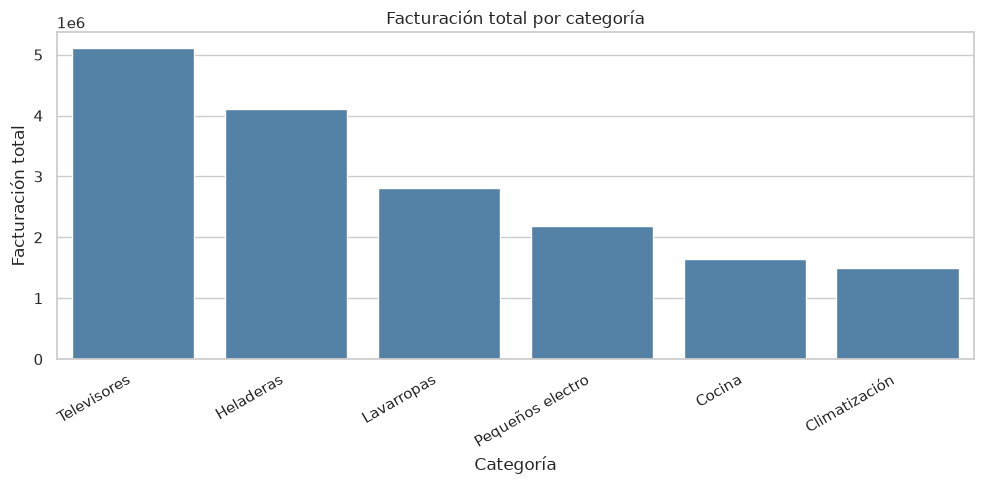

In [35]:
facturacion_categoria = (
    df.groupby("Categoria", as_index=False)["Importe_Final"]
    .sum()
    .sort_values("Importe_Final", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=facturacion_categoria,
    x="Categoria",
    y="Importe_Final",
    color="steelblue"
)

plt.title("Facturación total por categoría")
plt.xlabel("Categoría")
plt.ylabel("Facturación total")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretación:** Televisores es la categoría con mayor facturación, seguida por Heladeras. Pequeños electro registra la mayor cantidad de unidades vendidas, pero no la mayor facturación, debido a que sus precios son menores.

### Gráfico 2: cantidad de operaciones por canal

**Pregunta:** ¿Qué canal registra una mayor cantidad de operaciones?

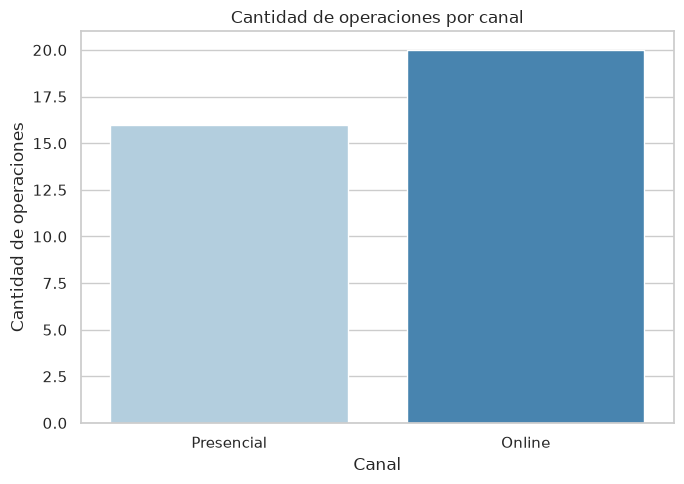

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Canal",
    hue="Canal",
    palette="Blues",
    legend=False
)

plt.title("Cantidad de operaciones por canal")
plt.xlabel("Canal")
plt.ylabel("Cantidad de operaciones")
plt.tight_layout()
plt.show()

**Interpretación:** El canal online registra 20 operaciones y el canal presencial 16. Por lo tanto, el canal online concentra la mayor cantidad de ventas.

### Gráfico 3: unidades vendidas por sucursal

**Pregunta:** ¿Qué sucursal vende la mayor cantidad de unidades?

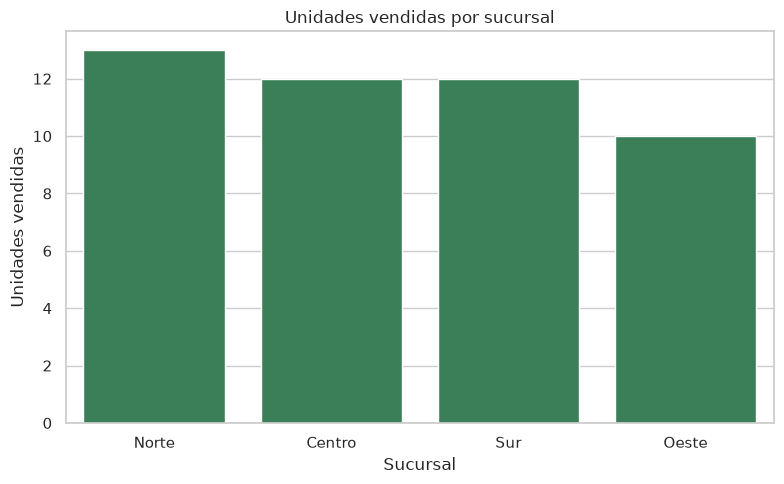

In [37]:
unidades_sucursal = (
    df.groupby("Sucursal", as_index=False)["Cantidad"]
    .sum()
    .sort_values("Cantidad", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=unidades_sucursal,
    x="Sucursal",
    y="Cantidad",
    color="seagreen"
)

plt.title("Unidades vendidas por sucursal")
plt.xlabel("Sucursal")
plt.ylabel("Unidades vendidas")
plt.tight_layout()
plt.show()

**Interpretación:** El gráfico permite comparar la cantidad total de unidades vendidas por cada sucursal e identificar cuál presenta el mayor volumen de productos comercializados.

### Gráfico 4: distribución de los importes por canal

**Pregunta:** ¿Cómo se distribuyen los importes finales de las operaciones online y presenciales?

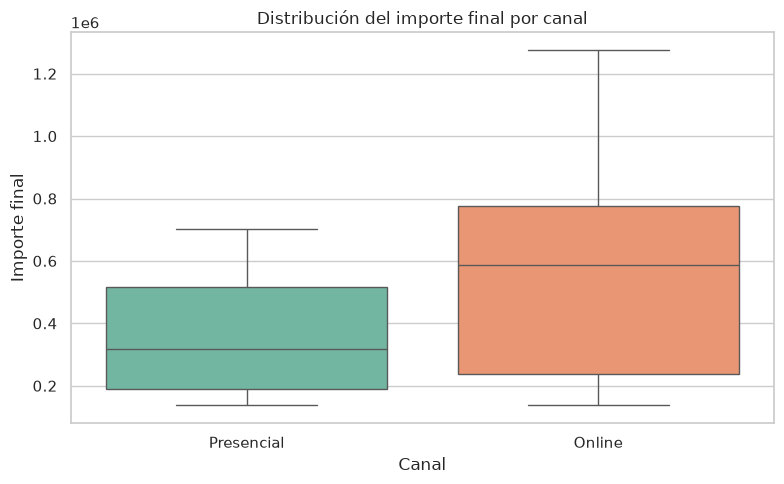

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Canal",
    y="Importe_Final",
    hue="Canal",
    palette="Set2",
    legend=False
)

plt.title("Distribución del importe final por canal")
plt.xlabel("Canal")
plt.ylabel("Importe final")
plt.tight_layout()
plt.show()

**Interpretación:** Las operaciones online presentan, en general, importes finales más elevados que las presenciales. El gráfico también permite observar la dispersión de los importes, la mediana y la posible presencia de valores extremos en cada canal.